In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.patches as mpatches

In [2]:
import sys,os, math
import numpy as np

In [3]:
import seaborn as sns
sns.set(style="ticks", color_codes=True, font_scale=1.25)
sns.set_style({"xtick.direction": "in", "ytick.direction": "in"})

In [4]:
import mdtraj as md

In [5]:
proot = 'GGKGG'
ff = 'amber99sb-star-ildn'
wat = 'tip3p' 

In [6]:
props = dict(boxstyle='round', facecolor='wheat', edgecolor='k', alpha=0.5)

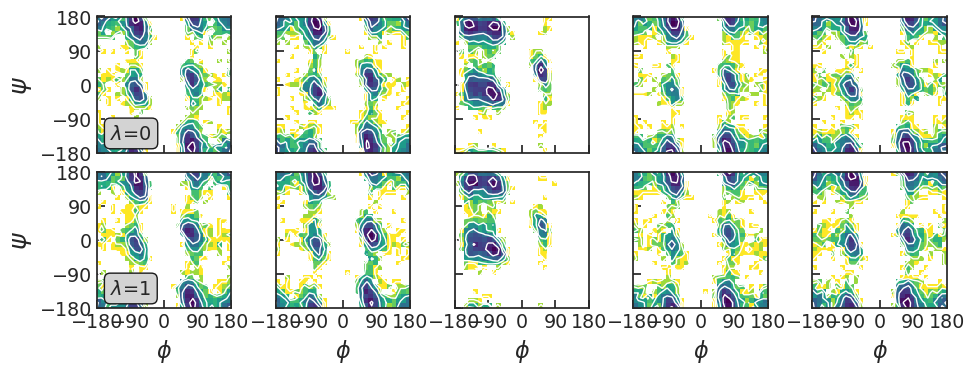

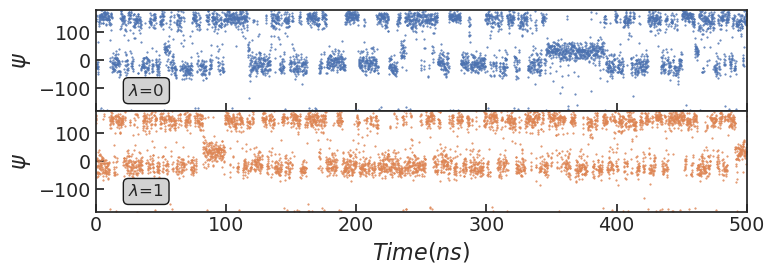

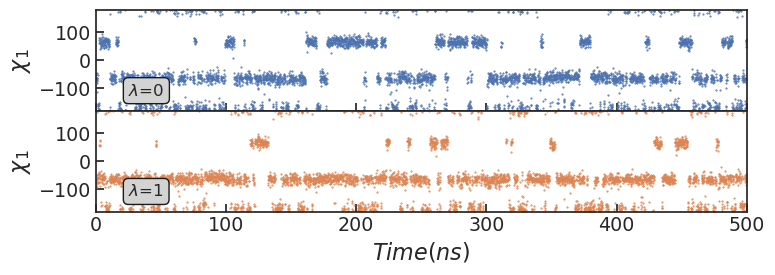

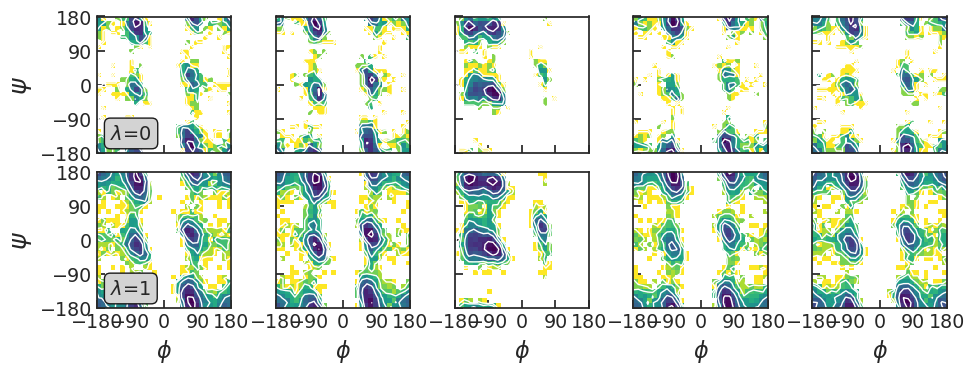

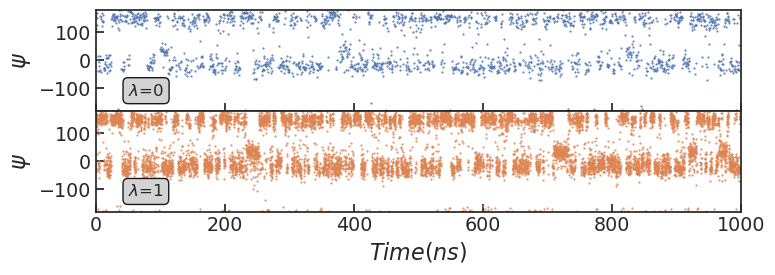

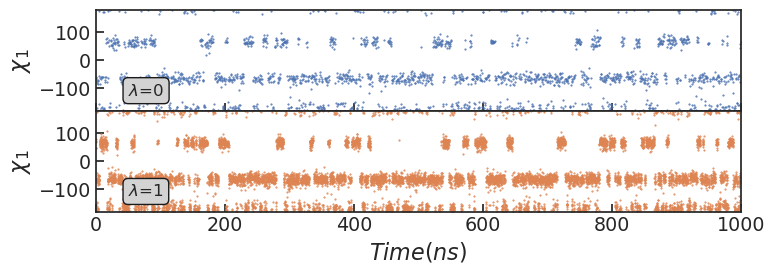

In [16]:
for k, charge in enumerate(['neutral', 'phys']):
    fig, ax = plt.subplots(2,5, figsize=(10,4), sharex=True, sharey=True)
    figg, axx = plt.subplots(2,1, figsize=(8,3), sharex=True, sharey=True)
    figgg, axxx = plt.subplots(2,1, figsize=(8,3), sharex=True, sharey=True)
    for lmbda in [0, 1]:
        pdb = "../data/%s_%s_%s_mut_%s_l%i_npt_berendsen.gro"%(proot, ff, wat, charge, lmbda)
        traj_pdb = md.load(pdb)
        atom_indices = traj_pdb.top.select("residue 1 to 7")
    
        xtc = "../data/%s_%s_%s_mut_%s_l%i_npt_proc.xtc"%(proot, ff, wat, charge, lmbda)

        traj = md.load_xtc(xtc, top=pdb, atom_indices=atom_indices, stride=5)
        phi = md.compute_phi(traj)
        psi = md.compute_psi(traj)
        chi1= md.compute_chi1(traj)

        for k in range(5):
            counts, ybins, xbins, image = ax[lmbda][k].hist2d(180./np.pi*phi[1][500:,k],180./np.pi*psi[1][500:,k], \
                bins=[np.linspace(-180,180,30), np.linspace(-180,180,30)], \
                cmap='viridis_r', \
                norm=mpl.colors.LogNorm(), density=True)
            ax[lmbda][k].contour(np.transpose(counts), extent=[xbins.min(), xbins.max(), ybins.min(), ybins.max()], \
                  linewidths=1, levels = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4], colors='white')
            
        ax[lmbda][0].text(0.1,0.1, r'$\lambda$=%g'%lmbda, fontsize=14, transform=ax[lmbda][0].transAxes, \
                          bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))

        axx[lmbda].plot(traj.time*1e-3, psi[1][:,2]*180/np.pi, '.' , ms=1, c='C%i'%lmbda, label=r'$\lambda$=%g'%lmbda)
        axx[lmbda].text(0.05,0.15, r'$\lambda$=%g'%lmbda, fontsize=12, transform=axx[lmbda].transAxes, \
                      bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))

        axxx[lmbda].plot(traj.time*1e-3, chi1[1][:,0]*180/np.pi, '.' , ms=1, c='C%i'%lmbda, label=r'$\lambda$=%g'%lmbda)
        axxx[lmbda].text(0.05,0.15, r'$\lambda$=%g'%lmbda, fontsize=12, transform=axxx[lmbda].transAxes, \
                      bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))
    
    axx[0].set_ylabel(r'$\psi$', fontsize=16); axx[1].set_ylabel(r'$\psi$', fontsize=16)
    axx[-1].set_xlabel(r'$Time (ns)$', fontsize=16)
    axx[0].set_ylim(-180,180); axx[0].set_xlim(0,traj.time[-1]*1e-3)
    figg.tight_layout(h_pad=0)
    figg.savefig("figures/%s_%s_%s_%s_l%i_psi.png"%(proot, ff, wat, charge, lmbda), \
                 dpi=300, transparent=True)

    axxx[0].set_ylabel(r'$\chi_1$', fontsize=16); axxx[1].set_ylabel(r'$\chi_1$', fontsize=16)
    axxx[-1].set_xlabel(r'$Time (ns)$', fontsize=16)
    axxx[0].set_ylim(-180,180); axxx[0].set_xlim(0,traj.time[-1]*1e-3)
    figgg.tight_layout(h_pad=0)
    figgg.savefig("figures/%s_%s_%s_%s_l%i_chi1.png"%(proot, ff, wat, charge, lmbda), \
                  dpi=300, transparent=True)

    [ax[i][0].set_ylabel(r'$\psi$', fontsize=18) for i in [0,1]]
    [ax[1][k].set_xlabel(r'$\phi$', fontsize=16) for k in range(5)]
    ax[lmbda][-1].set_xlim(-180,180)
    ax[lmbda][-1].set_ylim(-180,180)
    ax[lmbda][-1].xaxis.set_ticks(range(-180,181,90))
    ax[lmbda][-1].yaxis.set_ticks(range(-180,181,90))
    fig.tight_layout(w_pad=0, h_pad=0)
    fig.savefig("figures/%s_%s_%s_%s_l%i_phi_psi.png"%(proot, ff, wat, charge, lmbda), \
                dpi=300, transparent=True)

# SASA

../analysis/GGKGG_soupF_XXXL_amber99sb-star-ildn_tip3p_neutral_l0_npt_sasa.xvg
../analysis/GGKGG_soupF_XXXL_amber99sb-star-ildn_tip3p_neutral_l1_npt_sasa.xvg
../analysis/GGKGG_soupF_XXXL_amber99sb-star-ildn_tip3p_phys_l0_npt_sasa.xvg
../analysis/GGKGG_soupF_XXXL_amber99sb-star-ildn_tip3p_phys_l1_npt_sasa.xvg


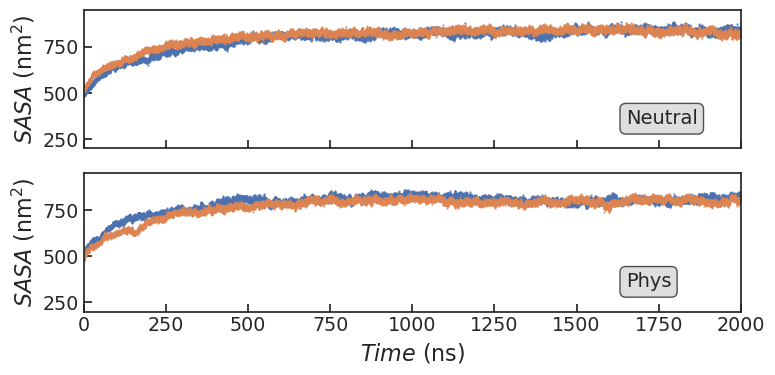

In [25]:
fig, ax = plt.subplots(2,1, figsize=(8,4), sharex=True, sharey=True)
props = dict(boxstyle='round', facecolor='lightgray', edgecolor='k', alpha=0.75)

soup = "soupF"

charge = ['neutral', 'phys']
for j,c in enumerate(charge):
    for i in [0,1]:
        file = "../analysis/%s_%s_XXXL_%s_%s_%s_l%g_npt_sasa.xvg"%(proot,soup, ff, wat, c, i)
        print (file)
        try:
            data = np.loadtxt(file, comments=["#", "@"])

            ax[j].plot(data[:,0]*1e-3, data[:,1], '.', ms=1, color='C%i'%i, label=r'$\lambda$=%g'%i)
        except Exception as e:
            print (e)
            pass
        
    ax[j].set_ylabel(r'$SASA$ (nm$^2$)', fontsize=16)
    ax[j].text(0.825, 0.175, r'%s'%c.capitalize(), fontsize=14, transform=ax[j].transAxes, \
        bbox=props)
ax[-1].set_xlabel(r'$Time$ (ns)', fontsize=16)
#lgnd = ax[0].legend(loc=4)
#lgnd.legend_handles[0].set_markersize(10); lgnd.legend_handles[1].set_markersize(10); 
ax[0].set_xlim(0, data[-1,0]*1e-3)
ax[0].set_ylim(200,950)
#plt.suptitle("%s"%proot.replace("F","(K2R)"), fontsize=14)
plt.tight_layout()
plt.savefig("figures/%s_%s_XXXL_%s_%s_sasa.png"%(proot, soup, ff, wat), dpi=300, transparent=True)

# Density

../analysis/GGKGG_soupF_XXXL_amber99sb-star-ildn_tip3p_neutral_l0_npt_densityNA.xvg not found.
../analysis/GGKGG_soupF_XXXL_amber99sb-star-ildn_tip3p_neutral_l1_npt_densityNA.xvg not found.


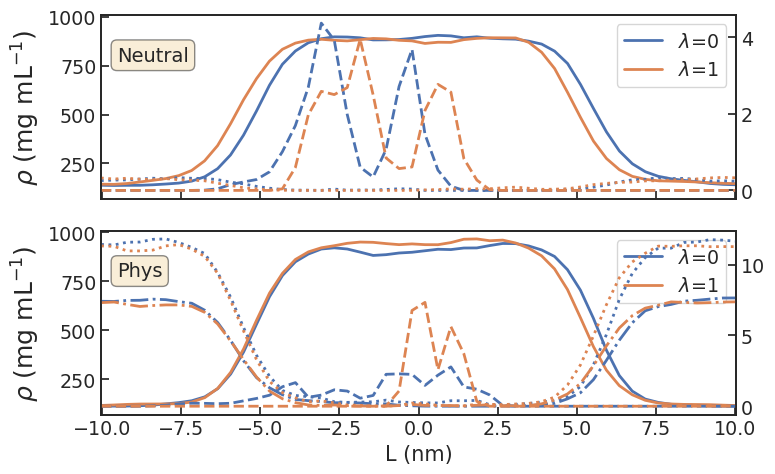

In [8]:
proot = 'GGKGG'
soup = 'soupF'
ff = 'amber99sb-star-ildn'
wat = 'tip3p'
charge = ['neutral', 'phys']

fig, ax = plt.subplots(2,1, figsize=(8,5), sharex=True, sharey=True)
for j,c in enumerate(charge):
    axt = ax[j].twinx()
    for i in [0,1]:
        try:
            file = "../analysis/%s_%s_XXXL_%s_%s_%s_l%g_npt_density.xvg"%(proot, soup, ff, wat, c, i)
            data = np.loadtxt(file, comments=["#", "@"])
            ax[j].plot(data[:,0], data[:,1], '-', lw=2
                    , color='C%i'%i, label=r'$\lambda$=%g'%i)
        except Exception as e:
            print (e)

        try:            
            file = "../analysis/%s_%s_XXXL_%s_%s_%s_l%g_npt_densityK2R.xvg"%(proot, soup, ff, wat, c, i)
            data = np.loadtxt(file, comments=["#", "@"])
            axt.plot(data[:,0], data[:,1], '--', lw=2
                , color='C%i'%i)
        except Exception as e:
            print (e)   
        try:            
            file = "../analysis/%s_%s_XXXL_%s_%s_%s_l%g_npt_densityCL.xvg"%(proot, soup, ff, wat, c, i)
            data = np.loadtxt(file, comments=["#", "@"])
            axt.plot(data[:,0], data[:,1], ls='dotted', lw=2
                , color='C%i'%i)
            
            file = "../analysis/%s_%s_XXXL_%s_%s_%s_l%g_npt_densityNA.xvg"%(proot, soup, ff, wat, c, i)
            data = np.loadtxt(file, comments=["#", "@"])
            axt.plot(data[:,0], data[:,1], ls='dashdot', lw=2
                , color='C%i'%i)
        except Exception as e:
            print (e)   
        
        ax[j].set_xlim(data[0,0], data[-1,0])
        ax[j].set_ylabel(r'$\rho$ (mg mL$^{-1}$)', fontsize=18)
        ax[j].legend(loc=1)
    ax[j].text(0.025, 0.75, r'%s'%c.capitalize(), fontsize=14, transform=ax[j].transAxes, \
        bbox=props)
    #ax.set_xlim(0,traj.time[-1])
#    ax[lmbda][-1].set_xlim(-180,180)
    #ax[lmbda][-1].set_ylim(-180,180)
#    ax[lmbda][-1].xaxis.set_ticks(range(-180,181,90))
    #ax[lmbda][-1].yaxis.set_ticks(range(-180,181,90))
ax[-1].set_xlabel('L (nm)')
plt.tight_layout()
fig.savefig("figures/%s_%s_XXXL_%s_%s_density.png"%(proot, soup, ff, wat), dpi=300, transparent=True)

Final frame = 499
../analysis/GGKGG_soup_XXXL_amber99sb-star-ildn_tip3p_neutral_l1_npt_density_bin491.xvg not found.
Final frame = 491
../analysis/GGKGG_soup_XXXL_amber99sb-star-ildn_tip3p_phys_l0_npt_density_bin472.xvg not found.
Final frame = 472
Final frame = 499


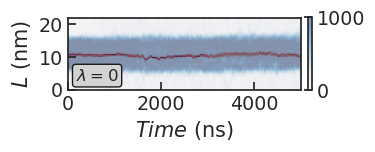

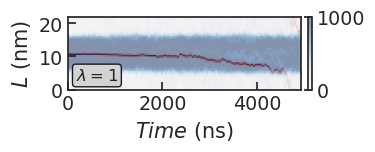

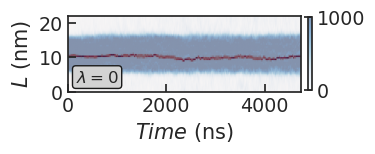

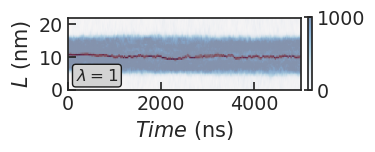

In [ ]:
proot = 'GGKGG'
ff = 'amber99sb-star-ildn'
wat = 'tip3p'
nbins = 500
exceptions = [[[], []],[[], []]]
for j, charge in enumerate(['neutral', 'phys']):

    for i in [0,1]:
        data = []
        dataH2O = []
        dataK2R = []

        #fig, ax = plt.subplots(2,1, figsize=(6,4), sharex=True)
        for k in range(nbins):
            file = "../analysis/%s_%s_XXXL_%s_%s_%s_l%g_npt_density_bin%i.xvg"%\
                (proot, soup,ff, wat, charge, i, k)
            try:
                data.append(np.loadtxt(file, comments=["#", "@"]))
                #ax[0].plot(data[-1][:,0], data[-1][:,1], '-', lw=2, color=plt.cm.Spectral(k/nbins))
            except Exception as e:
                print (e)
                break
            
            #file = "../analysis/%s_%s_XXXL_%s_%s_%s_l%g_npt_densityH2O_bin%i.xvg"%\
            #    (proot, soup, ff, wat, charge, i, k)
            #try:
            #    dataH2O.append(np.loadtxt(file, comments=["#", "@"]))
            #    ax[0].plot(dataH2O[-1][:,0], dataH2O[-1][:,1], '-', lw=2, color=plt.cm.Blues(k/nbins))
            #except Exception as e:
            #    print (e)
            #    break
            
            file = "../analysis/%s_%s_XXXL_%s_%s_%s_l%g_npt_densityK2R_bin%i.xvg"%\
                (proot, soup, ff, wat, charge, i, k)
            try:
                dataK2R.append(np.loadtxt(file, comments=["#", "@"]))
            #    ax[1].plot(dataK2R[-1][:,0], dataK2R[-1][:,1], lw=2, color=plt.cm.Spectral(k/nbins))
            #    if np.abs(dataK2R[-1][np.argmax(dataK2R[-1][:,1]), 0]) > 3.8:
            #        exceptions[j][i].append(k)
            except Exception as e:
                print (e)
            #    break
        print ("Final frame = %i"%k)
        #ax[-1].set_xlim(-10,10)

        #ax[0].set_ylim(0,1300); ax[1].set_ylim(0,50)
        #ax[-1].set_xlabel('L (nm)')
        #ax[0].set_ylabel(r'$\rho_{protein}$'); ax[1].set_ylabel(r'$\rho_{K2R}$')

        #plt.tight_layout(h_pad=0)

        fig, ax = plt.subplots(figsize=(4,2))
        #masked_data = np.ma.masked_where(np.vstack([x[:,1] for x in dataK2R]).transpose() == 0., \
        #                                 np.vstack([x[:,1] for x in dataK2R]).transpose())
        #ax.imshow(masked_data,  extent=[0,500, 0, 22], \
        #          alpha=1, cmap='Reds')
        try:
            ax.imshow(np.vstack([x[:,1] for x in dataK2R]).transpose(),  extent=[0,(k+1)*10, 0, 22], \
              alpha=1, cmap='Reds')
        except Exception as e:
            #break
            print (e)
        try:
            im = ax.imshow(np.vstack([x[:,1] for x in data]).transpose(), extent=[0,(k+1)*10, 0, 22],\
                alpha=0.5, cmap='Blues', vmin=0, vmax=1000)
            #plt.colorbar(im,fraction=0.018, pad=0.05)
            plt.colorbar(im, fraction=0.015, pad=0.03)
        except Exception as e:
            print (e)
        #ax.set_aspect(35)
        ax.set_aspect(70)
        ax.set_xlabel('$Time$ (ns)')
        ax.set_ylabel('$L$ (nm)')
        ax.set_yticks(np.arange(0,25,10))
        ax.text(0.035,0.125,r'$\lambda=$%i'%i, fontsize=12, transform=ax.transAxes, \
               bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round', pad=0.2))    
        plt.tight_layout()
        plt.savefig("figures/%s_%s_XXXL_%s_%s_%s_l%i_density.png"%(proot, soup, ff, wat, charge, i), dpi=300, transparent=True)


In [20]:
for j, charge in enumerate(['neutral', 'phys']):
    for i in [0,1]:
        switch_cum = []
        print ("Exceptions for %s, lambda=%s: %s"%(charge, i, exceptions[j][i]))
        print ("Exceptions for %s, lambda=%s in ns:"%(charge, i), 10*np.array(exceptions[j][i]))
        for x in exceptions[j][i]:
            switch_cum.append(int((10*x - 500)/7.5) - 1)

        print (switch_cum)
        print ()

Exceptions for neutral, lambda=0: [104, 105, 106, 108, 109, 117, 118, 134, 139, 140, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153]
Exceptions for neutral, lambda=0 in ns: [1040 1050 1060 1080 1090 1170 1180 1340 1390 1400 1440 1450 1460 1470
 1480 1490 1500 1510 1520 1530]
[71, 72, 73, 76, 77, 88, 89, 111, 117, 119, 124, 125, 127, 128, 129, 131, 132, 133, 135, 136]

Exceptions for neutral, lambda=1: [137, 138]
Exceptions for neutral, lambda=1 in ns: [1370 1380]
[115, 116]

Exceptions for phys, lambda=0: [165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]
Exceptions for phys, lambda=0 in ns: [1650 1660 1670 1680 1690 1700 1710 1720 1730 1740 1750 1760 1770 1780
 1790 1800 1810 1820 1830 1880 1890 1900 1910 1920 1930 1940 1950 1960
 1970 1980 1990 2000]
[152, 153, 155, 156, 157, 159, 160, 161, 163, 164, 165, 167, 168, 169, 171, 172, 173, 175, 176, 183, 184, 185, 187, 188, 189,

## Torsions

In [21]:
proot = "GGKGG"
ff = 'amber99sb-star-ildn'
wat = 'tip3p'
soup = 'soup'

In [ ]:
for k, charge in enumerate(['neutral', 'phys']):
    fig, ax = plt.subplots(2,5, figsize=(10,4), sharex=True, sharey=True)
    figg, axx = plt.subplots(2,1, figsize=(8,3), sharex=True, sharey=True)
    figgg, axxx = plt.subplots(2,1, figsize=(8,3), sharex=True, sharey=True)
    for lmbda in [0, 1]:
        pdb = "../data/%s_%s_XXXL_%s_%s_%s_l%i_npt_berendsen.gro"%(proot, soup, ff, wat, charge, lmbda)
        traj_pdb = md.load(pdb)
        atom_indices = traj_pdb.top.select("residue 1 to 7")
    
        xtc = "../data/%s_%s_XXXL_%s_%s_%s_l%i_npt_proc.xtc"%(proot, soup, ff, wat, charge, lmbda)

        traj = md.load_xtc(xtc, top=pdb, atom_indices=atom_indices, stride=10)
        phi = md.compute_phi(traj)
        psi = md.compute_psi(traj)
        chi1= md.compute_chi1(traj)

        for k in range(5):
            counts, ybins, xbins, image = ax[lmbda][k].hist2d(180./np.pi*phi[1][500:,k],180./np.pi*psi[1][500:,k], \
                bins=[np.linspace(-180,180,30), np.linspace(-180,180,30)], \
                cmap='viridis_r', \
                norm=mpl.colors.LogNorm(), density=True)
            ax[lmbda][k].contour(np.transpose(counts), extent=[xbins.min(), xbins.max(), ybins.min(), ybins.max()], \
                  linewidths=1, levels = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4], colors='white')
            
        ax[lmbda][0].text(0.1,0.1, r'$\lambda$=%g'%lmbda, fontsize=14, transform=ax[lmbda][0].transAxes, \
                          bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))

        axx[lmbda].plot(traj.time*1e-3, psi[1][:,2]*180/np.pi, '.' , ms=1, c='C%i'%lmbda, label=r'$\lambda$=%g'%lmbda)
        axx[lmbda].text(0.05,0.15, r'$\lambda$=%g'%lmbda, fontsize=12, transform=axx[lmbda].transAxes, \
                      bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))

        axxx[lmbda].plot(traj.time*1e-3, chi1[1][:,0]*180/np.pi, '.' , ms=1, c='C%i'%lmbda, label=r'$\lambda$=%g'%lmbda)
        axxx[lmbda].text(0.05,0.15, r'$\lambda$=%g'%lmbda, fontsize=12, transform=axxx[lmbda].transAxes, \
                      bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))
    
    axx[0].set_ylabel(r'$\psi$', fontsize=16); axx[1].set_ylabel(r'$\psi$', fontsize=16)
    axx[-1].set_xlabel(r'$Time (ns)$', fontsize=16)
    axx[0].set_ylim(-180,180); axx[0].set_xlim(0,traj.time[-1]*1e-3)
    figg.tight_layout(h_pad=0)
    figg.savefig("figures/%s_%s_XXXL_%s_%s_%s_l%i_psi.png"%(proot, soup, ff, wat, charge, lmbda), \
                 dpi=300, transparent=True)

    axxx[0].set_ylabel(r'$\chi_1$', fontsize=16); axxx[1].set_ylabel(r'$\chi_1$', fontsize=16)
    axxx[-1].set_xlabel(r'$Time (ns)$', fontsize=16)
    axxx[0].set_ylim(-180,180); axxx[0].set_xlim(0,traj.time[-1]*1e-3)
    figgg.tight_layout(h_pad=0)
    figgg.savefig("figures/%s_%s_XXXL_%s_%s_%s_l%i_chi1.png"%(proot, soup, ff, wat, charge, lmbda), \
                  dpi=300, transparent=True)

    [ax[i][0].set_ylabel(r'$\psi$', fontsize=18) for i in [0,1]]
    [ax[1][k].set_xlabel(r'$\phi$', fontsize=16) for k in range(5)]
    ax[lmbda][-1].set_xlim(-180,180)
    ax[lmbda][-1].set_ylim(-180,180)
    ax[lmbda][-1].xaxis.set_ticks(range(-180,181,90))
    ax[lmbda][-1].yaxis.set_ticks(range(-180,181,90))
    fig.tight_layout(w_pad=0, h_pad=0)
    fig.savefig("figures/%s_%s_XXXL_%s_%s_%s_l%i_phi_psi.png"%(proot, soup, ff, wat, charge, lmbda), \
                dpi=300, transparent=True)

## Benzene

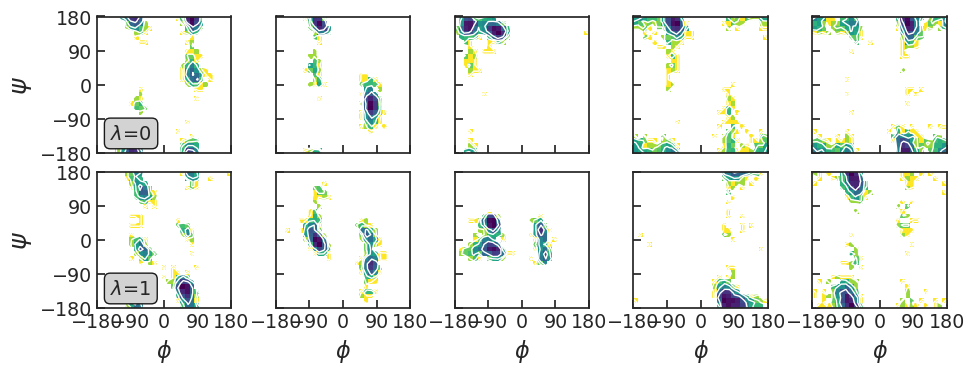

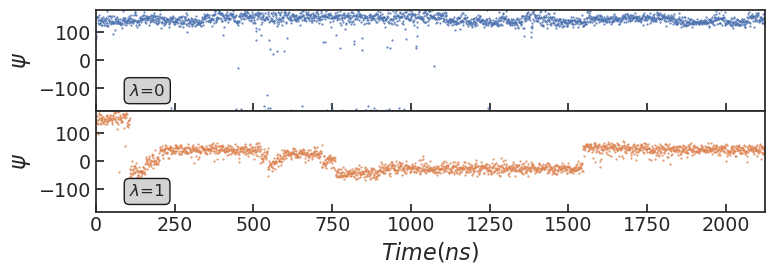

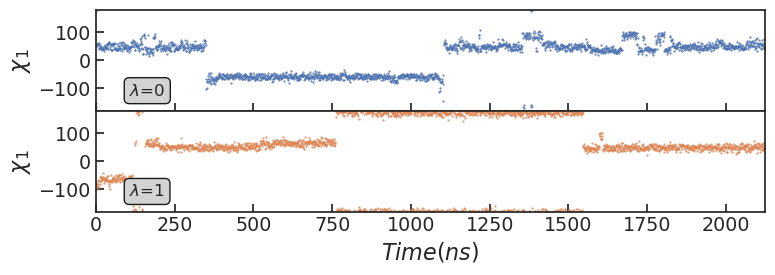

In [9]:
wat = "ben"
fig, ax = plt.subplots(2,5, figsize=(10,4), sharex=True, sharey=True)
figg, axx = plt.subplots(2,1, figsize=(8,3), sharex=True, sharey=True)
figgg, axxx = plt.subplots(2,1, figsize=(8,3), sharex=True, sharey=True)
for lmbda in [0, 1]:
    pdb = "../data/%s_%s_%s_mut_l%i_npt_berendsen.gro"%(proot, ff, wat, lmbda)
    traj_pdb = md.load(pdb)
    atom_indices = traj_pdb.top.select("residue 1 to 7")

    xtc = "../data/%s_%s_%s_mut_l%i_npt.xtc"%(proot, ff, wat, lmbda)

    traj = md.load_xtc(xtc, top=pdb, atom_indices=atom_indices, stride=50)
    phi = md.compute_phi(traj)
    psi = md.compute_psi(traj)
    chi1= md.compute_chi1(traj)

    for k in range(5):
        counts, ybins, xbins, image = ax[lmbda][k].hist2d(180./np.pi*phi[1][500:,k],180./np.pi*psi[1][500:,k], \
            bins=[np.linspace(-180,180,30), np.linspace(-180,180,30)], \
            cmap='viridis_r', \
            norm=mpl.colors.LogNorm(), density=True)
        ax[lmbda][k].contour(np.transpose(counts), extent=[xbins.min(), xbins.max(), ybins.min(), ybins.max()], \
              linewidths=1, levels = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4], colors='white')
        
    ax[lmbda][0].text(0.1,0.1, r'$\lambda$=%g'%lmbda, fontsize=14, transform=ax[lmbda][0].transAxes, \
                      bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))

    axx[lmbda].plot(traj.time*1e-3, psi[1][:,2]*180/np.pi, '.' , ms=1, c='C%i'%lmbda, label=r'$\lambda$=%g'%lmbda)
    axx[lmbda].text(0.05,0.15, r'$\lambda$=%g'%lmbda, fontsize=12, transform=axx[lmbda].transAxes, \
                  bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))

    axxx[lmbda].plot(traj.time*1e-3, chi1[1][:,0]*180/np.pi, '.' , ms=1, c='C%i'%lmbda, label=r'$\lambda$=%g'%lmbda)
    axxx[lmbda].text(0.05,0.15, r'$\lambda$=%g'%lmbda, fontsize=12, transform=axxx[lmbda].transAxes, \
                  bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))

axx[0].set_ylabel(r'$\psi$', fontsize=16); axx[1].set_ylabel(r'$\psi$', fontsize=16)
axx[-1].set_xlabel(r'$Time (ns)$', fontsize=16)
axx[0].set_ylim(-180,180); axx[0].set_xlim(0,traj.time[-1]*1e-3)
figg.tight_layout(h_pad=0)
figg.savefig("figures/%s_%s_%s_psi.png"%(proot, ff, wat), \
             dpi=300, transparent=True)

axxx[0].set_ylabel(r'$\chi_1$', fontsize=16); axxx[1].set_ylabel(r'$\chi_1$', fontsize=16)
axxx[-1].set_xlabel(r'$Time (ns)$', fontsize=16)
axxx[0].set_ylim(-180,180); axxx[0].set_xlim(0,traj.time[-1]*1e-3)
figgg.tight_layout(h_pad=0)
figgg.savefig("figures/%s_%s_%s_chi1.png"%(proot, ff, wat), \
              dpi=300, transparent=True)

[ax[i][0].set_ylabel(r'$\psi$', fontsize=18) for i in [0,1]]
[ax[1][k].set_xlabel(r'$\phi$', fontsize=16) for k in range(5)]
ax[lmbda][-1].set_xlim(-180,180)
ax[lmbda][-1].set_ylim(-180,180)
ax[lmbda][-1].xaxis.set_ticks(range(-180,181,90))
ax[lmbda][-1].yaxis.set_ticks(range(-180,181,90))
fig.tight_layout(w_pad=0, h_pad=0)
fig.savefig("figures/%s_%s_%s_phi_psi.png"%(proot, ff, wat), \
            dpi=300, transparent=True)

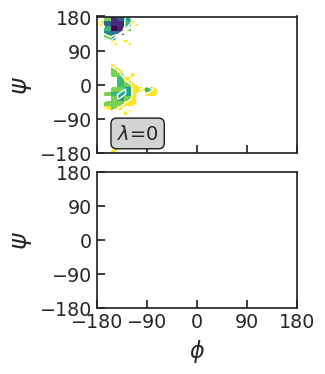

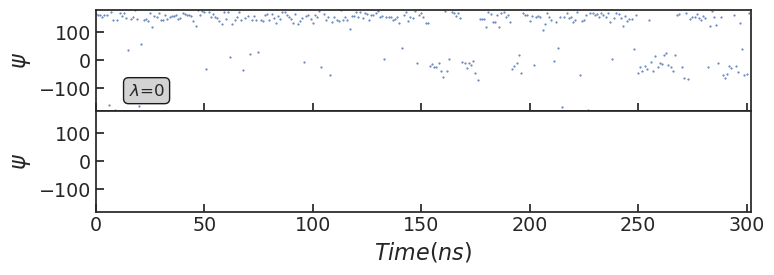

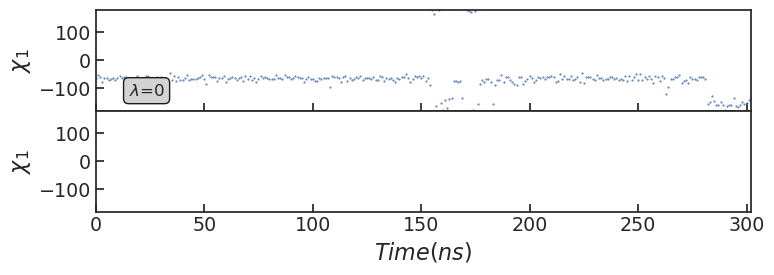

In [ ]:
wat = "ben"
fig, ax = plt.subplots(2,1, figsize=(3.5,4), sharex=True, sharey=True)
figg, axx = plt.subplots(2,1, figsize=(8,3), sharex=True, sharey=True)
figgg, axxx = plt.subplots(2,1, figsize=(8,3), sharex=True, sharey=True)
proot='lys'
for lmbda in [0, 1]:
    pdb = "../data/%s_%s_%s_mut_l%i_npt_berendsen.gro"%(proot, ff, wat, lmbda)
    traj_pdb = md.load(pdb)
    atom_indices = traj_pdb.top.select("residue 1 to 3")
    xtc = "../data/%s_%s_%s_mut_l%i_npt.xtc"%(proot, ff, wat, lmbda)

    traj = md.load_xtc(xtc, top=pdb, atom_indices=atom_indices, stride=50)
    phi = md.compute_phi(traj)
    psi = md.compute_psi(traj)
    chi1= md.compute_chi1(traj)

    counts, ybins, xbins, image = ax[lmbda].hist2d(180./np.pi*np.ravel(phi[1])[50:],180./np.pi*np.ravel(psi[1])[50:], \
        bins=[np.linspace(-180,180,30), np.linspace(-180,180,30)], \
        cmap='viridis_r', \
        norm=mpl.colors.LogNorm(), density=True)
    ax[lmbda].contour(np.transpose(counts), extent=[xbins.min(), xbins.max(), ybins.min(), ybins.max()], \
          linewidths=1, levels = [1e-6, 3e-6, 1e-5, 3e-5, 1e-4], colors='white')
        
    ax[lmbda].text(0.1,0.1, r'$\lambda$=%g'%lmbda, fontsize=14, transform=ax[lmbda].transAxes, \
                      bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))

    axx[lmbda].plot(traj.time*1e-3, np.ravel(psi[1])*180/np.pi, '.' , ms=1, c='C%i'%lmbda, label=r'$\lambda$=%g'%lmbda)
    axx[lmbda].text(0.05,0.15, r'$\lambda$=%g'%lmbda, fontsize=12, transform=axx[lmbda].transAxes, \
                  bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))

    axxx[lmbda].plot(traj.time*1e-3, np.ravel(chi1[1])*180/np.pi, '.' , ms=1, c='C%i'%lmbda, label=r'$\lambda$=%g'%lmbda)
    axxx[lmbda].text(0.05,0.15, r'$\lambda$=%g'%lmbda, fontsize=12, transform=axxx[lmbda].transAxes, \
                  bbox=dict(edgecolor='k', facecolor='lightgray', boxstyle='round'))

axx[0].set_ylabel(r'$\psi$', fontsize=16); axx[1].set_ylabel(r'$\psi$', fontsize=16)
axx[-1].set_xlabel(r'$Time (ns)$', fontsize=16)
axx[0].set_ylim(-180,180); axx[0].set_xlim(0,traj.time[-1]*1e-3)
figg.tight_layout(h_pad=0)
figg.savefig("figures/%s_%s_%s_psi.png"%(proot, ff, wat), \
             dpi=300, transparent=True)

axxx[0].set_ylabel(r'$\chi_1$', fontsize=16); axxx[1].set_ylabel(r'$\chi_1$', fontsize=16)
axxx[-1].set_xlabel(r'$Time (ns)$', fontsize=16)
axxx[0].set_ylim(-180,180); axxx[0].set_xlim(0,traj.time[-1]*1e-3)
figgg.tight_layout(h_pad=0)
figgg.savefig("figures/%s_%s_%s_chi1.png"%(proot, ff, wat), \
              dpi=300, transparent=True)

[ax[i].set_ylabel(r'$\psi$', fontsize=18) for i in [0,1]]
ax[1].set_xlabel(r'$\phi$', fontsize=16)
ax[-1].set_xlim(-180,180)
ax[-1].set_ylim(-180,180)
ax[-1].xaxis.set_ticks(range(-180,181,90))
ax[-1].yaxis.set_ticks(range(-180,181,90))
fig.tight_layout(w_pad=0, h_pad=0)
fig.savefig("figures/%s_%s_%s_phi_psi.png"%(proot, ff, wat), \
            dpi=300, transparent=True)